In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from keras.applications import vgg16
from keras.preprocessing.image import load_img,img_to_array
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
imgs_path = "archive/images/"
imgs_model_width, imgs_model_height = 224, 224

In [3]:
files = [imgs_path + x for x in os.listdir(imgs_path) if "jpg" in x]
print("Total number of images:", len(files))

Total number of images: 44441


# EDA и визуализация

In [4]:
styles = pd.read_csv("archive/styles.csv", on_bad_lines='skip')

# Товары для мужчин vs товары для женщин

In [5]:
fig = px.pie(styles, styles['gender'], color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_layout(title="Распределение товаров", width=800, height=800, font=dict(family="Segoe UI semilight", size=16))
fig.show()

In [8]:
catcounts=(styles['masterCategory']).value_counts()
catcounts

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

# Наиболее популярные категории

In [9]:
fig = go.Figure([go.Bar(x=catcounts.index, y=catcounts.values, text=catcounts.values, marker_color='darkkhaki')])
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(title="Топ категории", width=1000, height=900, xaxis_title='Категория',
                  yaxis_title='Количество покупок', font=dict(family="Segoe UI semilight", size=16))
fig.show()

Большей популярностью пользуется одежда.

# High season покупок

In [12]:
seasons=(styles['season']).value_counts()
seasons

season
Summer    21472
Fall      11431
Winter     8517
Spring     2983
Name: count, dtype: int64

In [13]:
fig = go.Figure(data=[go.Scatter(x=seasons.index, y=seasons.values, mode='markers',
    marker=dict(color=['rgb(93, 164, 214)', 'rgb(255, 144, 14)', 'rgb(44, 160, 101)', 'rgb(255, 65, 54)'],
                opacity=[0.6, 0.7, 0.8, 1], size=[123, 65, 49, 17]))])
fig.update_layout(width=900, height=900, title="Зависимость количества покупок от времени года", xaxis_title='Сезон', yaxis_title='Количество',
                  font=dict(family="Segoe UI semilight", size=16))
fig.show()

3/4 товаров покупаются летом и осенью.

# Наиболее популярные типы товаров

In [15]:
articles = (styles['articleType']).value_counts()
fig = go.Figure([go.Bar(x=articles.index[:15], y=articles.values[:15], text=articles.values[:15], marker_color='darkmagenta')])
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(title="Топ 15 категорий", xaxis_title='Категория', yaxis_title='Количество покупок',
                  width=950, height=750, font=dict(family="Segoe UI semilight", size=16))
fig.show()

Футболки и рубашки - лидеры продаж. Очевидно, это наиболее подходящая одежда для лета и осени в регионе.

# Извлечение признаков одного изображения

Для сокращения времени выполнения алгоритма сократим данные до 4000 изображений для предотвращения остановки ядра

In [16]:
files=files[0:4001]

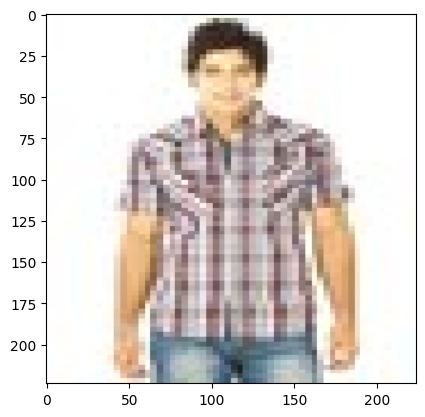

Пример данных


In [17]:
original = load_img(files[433], target_size=(imgs_model_width, imgs_model_height))
plt.imshow(original)
plt.show()
print("Пример данных")

На вход сети будут подаваться 3-х канальные изображения 224х224

In [18]:
# подгрузим сеть ImageNet с весами
vgg_model = vgg16.VGG16(weights='imagenet');
# сеть прогнозирует принадлежность к классу, поэтому удалим последние слои, чтобы получить признаки
feat_extractor = Model(inputs=vgg_model.input, outputs=vgg_model.get_layer("fc2").output);
# посмотрим на архитектуру сети
feat_extractor.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 65s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

С помощью **preprocess_input** изображения преобразуются из RGB в BGR, затем каждый цветовой канал центрируется по отношению к набору данных ImageNet без масштабирования.

In [19]:
numpy_image = img_to_array(original)
# преобразуем изображение в массив
# добавим одно измерение
# входные данные должны иметь вид (batchsize, height, width, channels)
image_batch = np.expand_dims(numpy_image, axis=0)
print('Размерность входных данных', image_batch.shape)
# prepare the image for the VGG model
processed_image = preprocess_input(image_batch.copy())

Размерность входных данных (1, 224, 224, 3)


In [20]:
img_features = feat_extractor.predict(processed_image)
print("Извлечены признаки одного изображения")
print("Количество признаков:", img_features.size)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
Извлечены признаки одного изображения
Количество признаков: 4096


# Проделаем те же действия с множеством изображений

In [21]:
importedImages = []
for f in files:
    filename = f
    original = load_img(filename, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    importedImages.append(image_batch)
images = np.vstack(importedImages)
processed_imgs = preprocess_input(images.copy())

In [22]:
imgs_features = feat_extractor.predict(processed_imgs)
print("Признаки извлечены")
imgs_features.shape

126/126 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step
Признаки извлечены


(4001, 4096)

In [23]:
print("Извлечено", imgs_features.shape[0], "признаков для каждого из", imgs_features.shape[1], "изображений.")

Извлечено 4001 признаков для каждого из 4096 изображений.


Подбор релевантных товаров осуществим на основе косинусного подобия - нормализованное скалярное произведение X и Y.

In [24]:
cosSimilarities = cosine_similarity(imgs_features)
# загрузим матрицу релевантности товаров в pandas df
cos_similarities_df = pd.DataFrame(cosSimilarities, columns=files, index=files)
cos_similarities_df.head()

,archive/images/10000.jpg,archive/images/10001.jpg,archive/images/10002.jpg,archive/images/10003.jpg,archive/images/10004.jpg,archive/images/10005.jpg,archive/images/10006.jpg,archive/images/10007.jpg,archive/images/10008.jpg,archive/images/10009.jpg,...,archive/images/14776.jpg,archive/images/14777.jpg,archive/images/14778.jpg,archive/images/14779.jpg,archive/images/14780.jpg,archive/images/14781.jpg,archive/images/14782.jpg,archive/images/14783.jpg,archive/images/14784.jpg,archive/images/14785.jpg
archive/images/10000.jpg,1.000000,0.531092,0.491198,0.705635,0.511560,0.471090,0.488218,0.476553,0.385720,0.450506,...,0.571807,0.547156,0.527502,0.527986,0.449823,0.440522,0.541325,0.523949,0.586378,0.566295
archive/images/10001.jpg,0.531092,1.000000,0.787532,0.529777,0.526021,0.390002,0.477478,0.346031,0.447088,0.412840,...,0.450812,0.539633,0.454634,0.517155,0.454958,0.497543,0.559589,0.522813,0.527288,0.559348
archive/images/10002.jpg,0.491198,0.787532,1.000000,0.544301,0.576467,0.397794,0.506847,0.417472,0.509537,0.487450,...,0.458313,0.632733,0.529795,0.527564,0.521976,0.592227,0.576121,0.534117,0.567778,0.574035
archive/images/10003.jpg,0.705635,0.529777,0.544301,1.000000,0.581718,0.562385,0.609192,0.572822,0.545917,0.584867,...,0.664132,0.634469,0.611185,0.589753,0.537546,0.559616,0.613136,0.602903,0.658034,0.629613
archive/images/10004.jpg,0.511560,0.526021,0.576467,0.581718,1.000000,0.466898,0.522210,0.302489,0.462060,0.422907,...,0.404608,0.517945,0.447776,0.409061,0.440283,0.463943,0.406548,0.401510,0.476445,0.415904


In [29]:
# функция подбора 4 релевантных товаров на основе выбранного
nb_closest_images = 4
def retrieve_relevant_products(given_img):
    print("     Выбранный товар")
    original = load_img(given_img, target_size=(imgs_model_width, imgs_model_height))
    plt.imshow(original)
    plt.show()
    print("    _____________________________")
    print("    Релевантные товары")
    closest_imgs = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1].index
    closest_imgs_scores = 100*cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1]
    plt.figure(figsize=(15, 10))
    for i in range(len(closest_imgs)):
        plt.subplot(1, nb_closest_images, i + 1)
        original = load_img(closest_imgs[i], target_size=(imgs_model_width, imgs_model_height))
        plt.imshow(original)
        plt.title(f"{round(closest_imgs_scores.iloc[i], 2)}%")
        plt.axis('off')
    plt.show()

     Выбранный товар


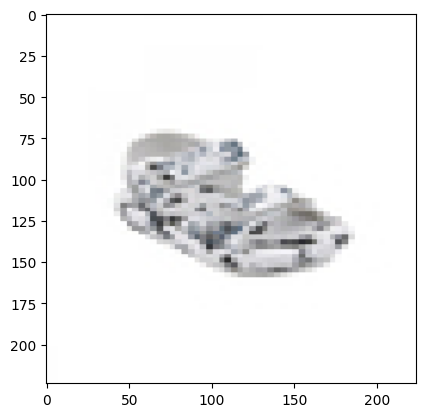

    _____________________________
    Релевантные товары


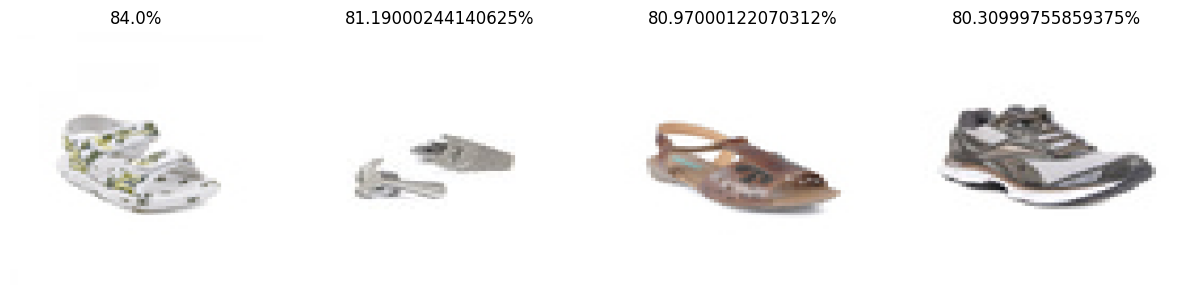

In [30]:
retrieve_relevant_products(files[651])

     Выбранный товар


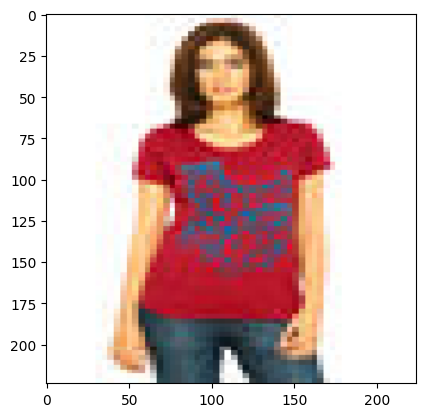

    _____________________________
    Релевантные товары


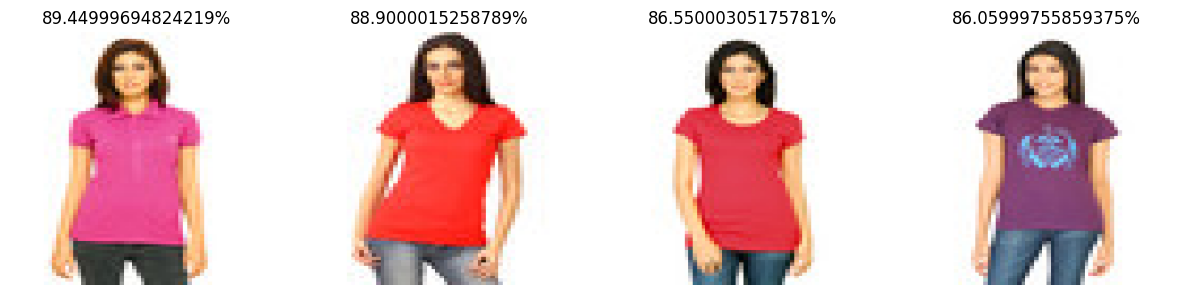

In [31]:
retrieve_relevant_products(files[792])

С одной стороны, рекомендации одежды на моделях имеют более высокую точность: на предметах одежды без модели сложнее определить пол.

С другой, рекомендации одежды на моделях считают товар схожим, если схожи модели.